# LAB-D4-04 Instructor Solution: Capstone - The Neural Network Investigation

> **INSTRUCTOR ONLY - EXCLUDE FROM PARTICIPANT RELEASES.** Cells through **Submit** mirror the participant sequence and complete its prompts for the selected anonymous profile. Profile-specific diagnoses and answers are solution material, not participant recovery content.

**Purpose:** Investigate one anonymous routing-code model profile, commit a falsifiable diagnosis, spend one primary experiment, unlock test evidence only after the decision, and defend the complete evidence chain.

**Objectives:** `OBJ-D4-01` through `OBJ-D4-08`, with primary evidence for `OBJ-D4-08`  
**Estimated duration:** 95 minutes work plus defense; complete single-profile CPU path under 12 minutes  
**Prerequisites:** all prior core labs, especially `LAB-D4-01`, `LAB-D4-02`, `LAB-D4-03`, and [LESSON-D4-08](../day-4/student-guide/day-4-student-guide.md#lesson-d4-08---capstone-defend-the-evidence-chain)  
**Environment:** CPU; PyTorch, NumPy, matplotlib, scikit-learn; fixed local digits data and cached baseline/recovery evidence; no network

Read the [Capstone Student Guide](capstone-student-guide.md) and [Capstone Rubric](capstone-rubric.md). The participant artifact is [capstone-starter.ipynb](capstone-starter.ipynb); this notebook is its canonical instructor-only solution.

In [1]:
import os
import hashlib
import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

torch.set_num_threads(1)
started_capstone = time.perf_counter()

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "courseware/shared/data/day-4/manifest.json").exists(): return candidate
    raise FileNotFoundError("Run from the repository checkout with courseware/shared/data/day-4 present.")

ROOT = find_repo_root(); DATA_DIR = ROOT / "courseware/shared/data/day-4"
manifest = json.loads((DATA_DIR / "manifest.json").read_text())
print(f"Python {platform.python_version()} | torch {torch.__version__} | scikit-learn {sklearn.__version__}")
print("Required device: CPU. Fixed seeds aid repeatability but do not imply cross-device bitwise equality.")

Python 3.11.8 | torch 2.6.0 | scikit-learn 1.9.0
Required device: CPU. Fixed seeds aid repeatability but do not imply cross-device bitwise equality.


## Case Brief: Routing-Code Recognition

The input is an 8x8 handwritten digit image. A routing system predicts one of ten codes. Misrouting a weak class is costly, but overall quality, generalization, latency, and size still matter. Profiles `A`, `B`, and `C` are anonymous; names, filenames, colors, and metadata do not state a cause.

In [2]:
PROFILE_ID = os.environ.get("DAY4_PROFILE", "A").strip().upper()
assert PROFILE_ID in {"A", "B", "C"}
selected_baseline_record = manifest["artifacts"][f"profile_{PROFILE_ID}_baseline"]
selected_baseline_path = DATA_DIR / selected_baseline_record["path"]
assert hashlib.sha256(selected_baseline_path.read_bytes()).hexdigest() == selected_baseline_record["sha256"]
baseline = np.load(selected_baseline_path, allow_pickle=False)
case_target = str(baseline["case_target"])
print("Assigned profile:", PROFILE_ID)
print("Assigned target:", case_target)

Assigned profile: A
Assigned target: Raise worst-class recall by at least 0.05 with no more than 0.02 overall validation-accuracy degradation.


## Fixed Split and Test Lock

The split hash is evidence. Training and validation arrays are bound now. Test indices remain behind a function gate until the primary experiment is interpreted and the decision record is complete.

In [3]:
digits = load_digits(); X_all = digits.images.astype(np.float32); y_all = digits.target.astype(np.int64)
splits = np.load(DATA_DIR / manifest["artifacts"]["fixed_splits"]["path"], allow_pickle=False)
train_indices, val_indices = splits["train_indices"], splits["val_indices"]
_locked_test_indices = splits["test_indices"]
split_hash = str(splits["split_hash"])
assert split_hash == manifest["fixed_split"]["hash"]
X_all_tensor = torch.tensor(X_all / 16.0, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)
TEST_AUTHORIZED = False
TEST_ACCESS_COUNT = 0

def access_test_split():
    global TEST_ACCESS_COUNT
    if not TEST_AUTHORIZED:
        raise PermissionError("Test is locked until the decision gate passes.")
    if TEST_ACCESS_COUNT:
        raise RuntimeError("The single authorized test access has already been consumed.")
    TEST_ACCESS_COUNT += 1
    return X_all_tensor[_locked_test_indices], y_all_tensor[_locked_test_indices]

try:
    access_test_split(); raise AssertionError("Test lock failed")
except PermissionError as error:
    print("Expected lock diagnostic:", error)
assert TEST_ACCESS_COUNT == 0
print("Fixed split hash:", split_hash)

Expected lock diagnostic: Test is locked until the decision gate passes.
Fixed split hash: c9a534c56d9b1bb069bc2295d7adf87517e34b69ea9a5b046b79a3b29470b3d9


In [4]:
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cpu")

def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

class DigitsMLP(nn.Module):
    def __init__(self, hidden=(32,), dropout=0.0):
        super().__init__(); layers = [nn.Flatten()]; input_dim = 64
        for width in hidden:
            layers.extend([nn.Linear(input_dim, width), nn.ReLU()])
            if dropout > 0: layers.append(nn.Dropout(dropout))
            input_dim = width
        layers.append(nn.Linear(input_dim, 10)); self.network = nn.Sequential(*layers)
    def forward(self, inputs): return self.network(inputs)

def evaluate_model(model, X, y):
    model.eval()
    with torch.inference_mode():
        logits = model(X); probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    predictions = probabilities.argmax(1); targets = y.cpu().numpy()
    return {
        "loss": float(nn.CrossEntropyLoss()(logits, y).item()),
        "accuracy": float(accuracy_score(targets, predictions)),
        "macro_f1": float(f1_score(targets, predictions, average="macro", zero_division=0)),
        "probabilities": probabilities, "predictions": predictions,
    }

def run_experiment(config, train_indices, val_indices):
    set_all_seeds(config["seed"])
    model = DigitsMLP(tuple(config["hidden"]), config["dropout"]).to(DEVICE)
    optimizer_class = {"adam": torch.optim.Adam, "adamw": torch.optim.AdamW, "sgd": torch.optim.SGD}[config["optimizer_name"]]
    extra = {"momentum": 0.9} if config["optimizer_name"] == "sgd" else {}
    optimizer = optimizer_class(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"], **extra)
    selected_labels = y_all[train_indices]
    if config["class_weight"]:
        counts = np.bincount(selected_labels, minlength=10); weights = len(selected_labels) / (10 * np.maximum(counts, 1))
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32))
    else: loss_fn = nn.CrossEntropyLoss()
    generator = torch.Generator().manual_seed(4403 + config["seed"])
    loader = DataLoader(TensorDataset(X_all_tensor[train_indices], y_all_tensor[train_indices]), batch_size=config["batch_size"], shuffle=True, generator=generator, num_workers=0)
    history = {name: [] for name in ["train_loss", "val_loss", "train_accuracy", "val_accuracy"]}; started = time.perf_counter()
    for _ in range(config["epochs"]):
        model.train()
        for X_batch, y_batch in loader:
            optimizer.zero_grad(); loss = loss_fn(model(X_batch), y_batch); loss.backward(); optimizer.step()
        train_metrics = evaluate_model(model, X_all_tensor[train_indices], y_all_tensor[train_indices])
        val_metrics = evaluate_model(model, X_all_tensor[val_indices], y_all_tensor[val_indices])
        for prefix, values in [("train", train_metrics), ("val", val_metrics)]:
            history[f"{prefix}_loss"].append(values["loss"]); history[f"{prefix}_accuracy"].append(values["accuracy"])
    return {"model": model, "config": dict(config), "history": history,
            "train": evaluate_model(model, X_all_tensor[train_indices], y_all_tensor[train_indices]),
            "validation": evaluate_model(model, X_all_tensor[val_indices], y_all_tensor[val_indices]),
            "training_seconds": time.perf_counter() - started,
            "parameter_count": sum(p.numel() for p in model.parameters()),
            "parameter_bytes": sum(p.numel() * p.element_size() for p in model.parameters())}

def benchmark_batch1(model, sample, warmup=20, repeats=100):
    model.eval(); timings = []
    with torch.inference_mode():
        for _ in range(warmup): model(sample)
        for _ in range(repeats):
            started = time.perf_counter(); model(sample); timings.append((time.perf_counter() - started) * 1000)
    return {"median_ms": float(np.median(timings)), "p90_ms": float(np.percentile(timings, 90)), "warmup": warmup, "repeats": repeats}

In [5]:
case_train_indices = np.asarray(baseline["case_train_indices"], dtype=np.int64)
BASELINE_CONFIG = json.loads(str(baseline["baseline_config_json"]))
expected_config_fields = {
    "hidden", "dropout", "optimizer_name", "learning_rate", "weight_decay",
    "class_weight", "epochs", "batch_size", "seed",
}
assert set(BASELINE_CONFIG) == expected_config_fields
assert len(case_train_indices) == len(np.unique(case_train_indices))
assert np.all(np.isin(case_train_indices, train_indices))
print("Selected case contract loaded; training examples:", len(case_train_indices))

Selected case contract loaded; training examples: 922


## Baseline Evidence Board: Facts First

Inspect curves, metrics, confusion, high-confidence errors, runtime, and size before naming a cause. Facts and inferences belong in different fields.

Baseline facts: {'train_accuracy': 0.9436008930206299, 'validation_accuracy': 0.8300835490226746, 'validation_macro_f1': 0.8013797243564431, 'worst_class_recall': 0.17142857611179352, 'training_seconds': 0.08, 'parameter_bytes': 9640, 'batch1_latency_ms': 0.0105}


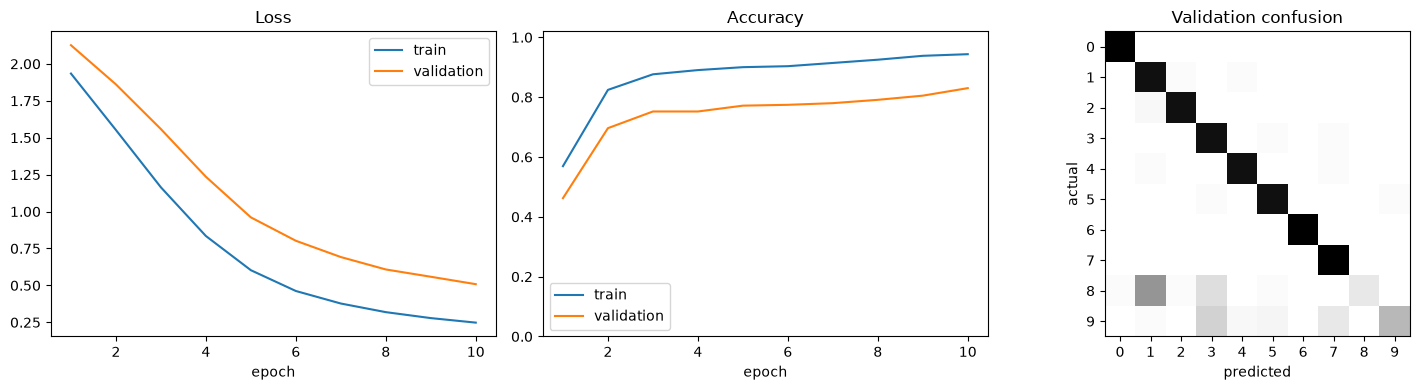

In [6]:
baseline_confusion = baseline["confusion"]
baseline_summary = {
    "train_accuracy": float(baseline["train_accuracy"][-1]),
    "validation_accuracy": float(baseline["val_accuracy"][-1]),
    "validation_macro_f1": float(f1_score(baseline["val_labels"], baseline["val_predictions"], average="macro", zero_division=0)),
    "worst_class_recall": float(baseline["class_recall"].min()),
    "training_seconds": float(baseline["training_seconds"]),
    "parameter_bytes": int(baseline["parameter_bytes"]),
    "batch1_latency_ms": float(baseline["latency_ms_median"]),
}
print("Baseline facts:", baseline_summary)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(baseline["epochs"], baseline["train_loss"], label="train"); axes[0].plot(baseline["epochs"], baseline["val_loss"], label="validation"); axes[0].set(title="Loss", xlabel="epoch"); axes[0].legend()
axes[1].plot(baseline["epochs"], baseline["train_accuracy"], label="train"); axes[1].plot(baseline["epochs"], baseline["val_accuracy"], label="validation"); axes[1].set(title="Accuracy", xlabel="epoch", ylim=(0,1.02)); axes[1].legend()
axes[2].imshow(baseline_confusion, cmap="Greys"); axes[2].set(title="Validation confusion", xlabel="predicted", ylabel="actual", xticks=range(10), yticks=range(10))
plt.tight_layout(); plt.show()

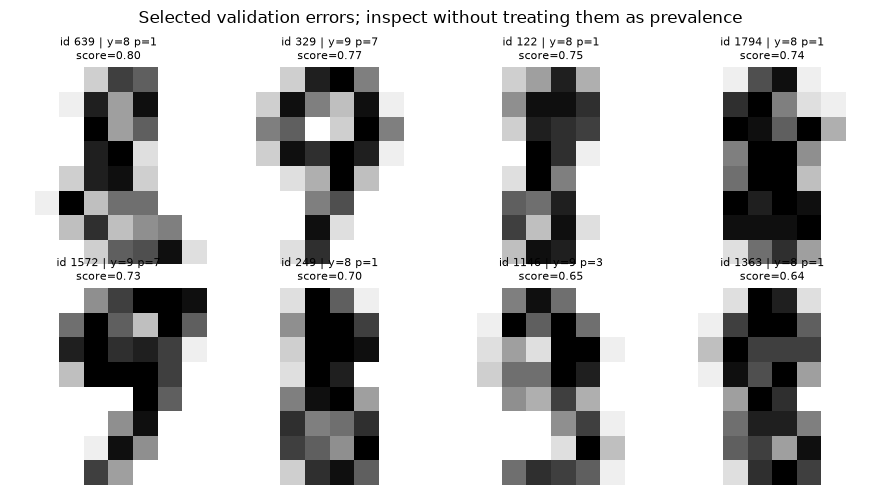

In [7]:
val_confidence = baseline["val_probabilities"].max(axis=1)
error_positions = np.flatnonzero(baseline["val_predictions"] != baseline["val_labels"])
shown = error_positions[np.argsort(val_confidence[error_positions])[::-1]][:8]
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for position, ax in zip(shown, axes.ravel()):
    sample_id = int(baseline["val_sample_ids"][position]); ax.imshow(X_all[sample_id], cmap="gray_r")
    ax.set_title(f"id {sample_id} | y={baseline['val_labels'][position]} p={baseline['val_predictions'][position]}\nscore={val_confidence[position]:.2f}", fontsize=8); ax.axis("off")
plt.suptitle("Selected validation errors; inspect without treating them as prevalence")
plt.tight_layout(); plt.show()

## Request Exactly One Evidence Card

Choose one: `class_counts`, `curve_dynamics`, `confidence_errors`, or `resource_profile`. Explain why it separates your top two hypotheses before revealing it.

In [8]:
EVIDENCE_REQUESTS = {
    "A": {
        "card": "class_counts",
        "top_two_hypotheses": "1) limited class support changes loss contribution; 2) representation or label ambiguity concentrates errors",
        "why_discriminating": "Counts directly test whether weak recall co-occurs with scarce training support; balanced counts would weaken the leading data-composition explanation without proving the representation alternative.",
    },
    "B": {
        "card": "curve_dynamics",
        "top_two_hypotheses": "1) high-capacity variance on constrained data; 2) split shift or unrepresentative training data",
        "why_discriminating": "A late train/validation divergence supports a variance mechanism; a persistent gap alone cannot eliminate split shift, so the card raises or lowers rather than proves the leading diagnosis.",
    },
    "C": {
        "card": "curve_dynamics",
        "top_two_hypotheses": "1) unstable or ineffective optimization; 2) insufficient representation capacity",
        "why_discriminating": "Oscillation or nonmonotonic loss under weak train and validation scores favors step-size instability; smooth convergence to a poor plateau would make capacity more competitive.",
    },
}
evidence_request = dict(EVIDENCE_REQUESTS[PROFILE_ID])
assert evidence_request["card"] in {"class_counts", "curve_dynamics", "confidence_errors", "resource_profile"}
assert all(value.strip() for value in evidence_request.values())

EVIDENCE_CARDS = {
    "class_counts": baseline["train_class_counts"].tolist(),
    "curve_dynamics": {"last_train_loss": float(baseline["train_loss"][-1]), "last_val_loss": float(baseline["val_loss"][-1]), "val_loss_range": float(np.ptp(baseline["val_loss"]))},
    "confidence_errors": {"errors": int(len(error_positions)), "errors_above_0_60": int(np.sum(val_confidence[error_positions] >= 0.60))},
    "resource_profile": {key: baseline_summary[key] for key in ["training_seconds", "parameter_bytes", "batch1_latency_ms"]},
}
requested_evidence = EVIDENCE_CARDS[evidence_request["card"]]
print("Requested card:", evidence_request["card"], requested_evidence)

Requested card: class_counts [107, 109, 106, 110, 109, 109, 109, 107, 24, 32]


## Diagnosis Gate

Rank data/composition, generalization/capacity, optimization, architecture, evaluation, and compute explanations. Name evidence that supports the leader and evidence that would make it wrong. The gate scores reasoning, not a secret label.

In [9]:
DIAGNOSIS_GATES = {
    "A": {
        "ranked_hypotheses": "1) data composition/class support; 2) representation or label ambiguity; 3) optimization; 4) evaluation; 5) compute",
        "primary_limitation": "Limited support for classes 8 and 9 reduces their contribution to the unweighted training objective and harms worst-class recall.",
        "supporting_metric": "Validation accuracy is about 0.830 while macro-F1 is about 0.801 and worst-class recall is about 0.171, so aggregate quality hides concentrated harm.",
        "supporting_curve_or_slice": "The authorized class-count card shows substantially fewer training examples for classes 8 and 9 than for the other classes.",
        "competing_explanation": "The compact representation or ambiguous labels could also concentrate errors in visually similar classes even with adequate support.",
        "disconfirming_evidence": "Class weighting fails to raise worst-class recall by at least 0.05, lowers validation accuracy by more than 0.02, or improves unrelated classes without helping the weak slice.",
        "target_connection": "Worst-class recall is the consequence-aware target; the aggregate-accuracy tolerance prevents solving the slice by sacrificing overall routing quality.",
        "confidence_and_limit": "Moderate confidence on this fixed split. Weighting is a sensitivity test, not proof that support is the sole causal mechanism.",
    },
    "B": {
        "ranked_hypotheses": "1) high variance from capacity on constrained data; 2) split shift; 3) label duplication/quality; 4) optimization; 5) compute",
        "primary_limitation": "A high-capacity network fitted to a small case subset has a large generalization gap consistent with variance.",
        "supporting_metric": "Training accuracy is 1.000 while validation accuracy is about 0.880, a gap near 0.120 despite useful absolute validation performance.",
        "supporting_curve_or_slice": "The authorized curve card shows training continuing to fit while validation remains lower late in training.",
        "competing_explanation": "A nonrepresentative split, duplicates, or label differences could create the same train/validation separation without capacity being primary.",
        "disconfirming_evidence": "A single regularizer neither reduces the gap by roughly 0.03 nor improves validation, or both training and validation become weak enough to indicate underfit.",
        "target_connection": "The target permits either a meaningful gap reduction or a defensible held-out improvement; gap shrinkage caused only by worse training is not success.",
        "confidence_and_limit": "Moderate confidence. The experiment tests a variance mechanism but cannot eliminate split shift on one fixed validation set.",
    },
    "C": {
        "ranked_hypotheses": "1) unstable or ineffective optimization; 2) insufficient representation capacity; 3) preprocessing/invariant defect; 4) data shift; 5) compute",
        "primary_limitation": "The supplied learning rate is excessively aggressive for this optimizer and prevents a stable useful fit.",
        "supporting_metric": "Training accuracy is only about 0.862 and validation accuracy about 0.783, so pure high variance is not the leading explanation.",
        "supporting_curve_or_slice": "The authorized curve card shows an unstable path rather than smooth convergence to a stable poor plateau.",
        "competing_explanation": "The compact representation may be underpowered, or a data/loss invariant may be wrong.",
        "disconfirming_evidence": "A bounded learning-rate correction does not smooth the path or improve validation accuracy by at least 0.05, or invariant checks expose a stronger implementation cause.",
        "target_connection": "The target requires both quality improvement and a more stable path, preventing a lucky final-epoch score from passing alone.",
        "confidence_and_limit": "Moderate confidence. One corrected step size narrows the mechanism; it does not prove architecture and data are irrelevant.",
    },
}
diagnosis_gate = dict(DIAGNOSIS_GATES[PROFILE_ID])
assert all(value.strip() for value in diagnosis_gate.values()), "Complete the diagnosis and disconfirming-evidence gate before spending the run."

## Choose One Primary Intervention

Allowed major fields: `hidden`, `dropout`, `optimizer_name`, `learning_rate`, `weight_decay`, or `class_weight`. Change exactly one. Predict observations in metrics, curves/slices, and resources before running.

In [10]:
MAJOR_FIELDS = {"hidden", "dropout", "optimizer_name", "learning_rate", "weight_decay", "class_weight"}
PRIMARY_CONFIG = dict(BASELINE_CONFIG)
PRIMARY_CHANGES = {"A": ("class_weight", True), "B": ("dropout", 0.5), "C": ("learning_rate", 0.003)}
primary_field, primary_value = PRIMARY_CHANGES[PROFILE_ID]
PRIMARY_CONFIG[primary_field] = primary_value

changed_fields = [field for field in MAJOR_FIELDS if PRIMARY_CONFIG[field] != BASELINE_CONFIG[field]]
assert len(changed_fields) == 1, f"One primary change required; received {changed_fields}"
assert PRIMARY_CONFIG["epochs"] <= 70
INTERVENTION_PREDICTIONS = {
    "A": {
        "changed_field": "class_weight",
        "mechanism": "Inverse-frequency class weighting makes errors from scarce classes contribute more strongly while data, representation, optimizer, and budget stay fixed.",
        "predicted_metric": "Worst-class recall rises by at least 0.05 and validation accuracy does not degrade by more than 0.02.",
        "predicted_curve_or_slice": "Recall for the weak class should recover; macro-F1 should move toward accuracy rather than only redistributing errors.",
        "predicted_resource_effect": "Parameter bytes stay exactly fixed; training time may move slightly because the weighted loss adds negligible work, and host latency should remain comparable.",
        "rejection_rule": "Reject or narrow the support mechanism if worst recall gains less than 0.05, aggregate accuracy falls more than 0.02, or gains do not occur in the weak slice.",
    },
    "B": {
        "changed_field": "dropout",
        "mechanism": "Dropout regularizes the high-capacity model while architecture width, data, optimizer, learning rate, and epochs remain fixed.",
        "predicted_metric": "Reduce the train/validation gap by about 0.03 or improve held-out validation without a material class-aware regression.",
        "predicted_curve_or_slice": "Training fit may decrease while validation follows more closely; a smaller gap caused only by collapsed training performance is not success.",
        "predicted_resource_effect": "Stored parameter bytes stay exactly fixed; training cost can rise slightly and batch-1 evaluation latency should remain broadly comparable because dropout is disabled in eval mode.",
        "rejection_rule": "Reject or narrow the variance mechanism if validation does not improve and the gap reduction is under about 0.03, or if regularization creates broad underfit.",
    },
    "C": {
        "changed_field": "learning_rate",
        "mechanism": "Reduce the Adam step size from 0.20 to 0.003 while keeping architecture, optimizer family, data, and epoch budget fixed.",
        "predicted_metric": "Validation accuracy improves by at least 0.05 and macro-F1/class recall recover.",
        "predicted_curve_or_slice": "Loss descends more smoothly with less oscillation; both training and validation improve, distinguishing optimization from pure variance.",
        "predicted_resource_effect": "Parameter bytes stay exactly fixed; training and warmed batch-1 latency remain comparable within host measurement noise.",
        "rejection_rule": "Reject or narrow the aggressive-step-size mechanism if the path remains unstable or validation improves by less than 0.05.",
    },
}
intervention_prediction = dict(INTERVENTION_PREDICTIONS[PROFILE_ID])
assert intervention_prediction["changed_field"] == changed_fields[0]
assert all(str(value).strip() for value in intervention_prediction.values())

## Run the Primary Experiment

The default path trains from a fresh model/optimizer/loader. Set recovery only after a technical failure and only after the diagnosis/intervention gates. Recovery succeeds only when the selected config fingerprint matches the anonymous cached run; it never supplies test evidence.

In [11]:
def config_fingerprint(config):
    return hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()

USE_RECOVERY_AFTER_TECHNICAL_FAILURE = os.environ.get("DAY4_USE_RECOVERY", "0") == "1"
primary_run = None
recovery_used = False
recovery_provenance = {"mode": "live", "artifact": None, "sha256": None, "fingerprint": None}
if not USE_RECOVERY_AFTER_TECHNICAL_FAILURE:
    primary_run = run_experiment(PRIMARY_CONFIG, case_train_indices, val_indices)
    primary_validation = primary_run["validation"]
    primary_history = primary_run["history"]
    primary_resources = {
        "training_seconds": primary_run["training_seconds"],
        "parameter_bytes": primary_run["parameter_bytes"],
        **benchmark_batch1(primary_run["model"], X_all_tensor[val_indices[:1]]),
    }
else:
    recovery_record = manifest["artifacts"][f"profile_{PROFILE_ID}_recovery"]
    recovery_path = DATA_DIR / recovery_record["path"]
    assert hashlib.sha256(recovery_path.read_bytes()).hexdigest() == recovery_record["sha256"]
    assert config_fingerprint(PRIMARY_CONFIG) == recovery_record["selection_fingerprint"], "No cached recovery matches this already-committed primary config."
    recovery = np.load(recovery_path, allow_pickle=False)
    forbidden_recovery_terms = ("cause", "diagnos", "intervention", "checkpoint", "test")
    assert not any(term in key.lower() for key in recovery.files for term in forbidden_recovery_terms)
    recovery_strings = " ".join(str(np.asarray(recovery[key]).tolist()) for key in recovery.files if np.asarray(recovery[key]).dtype.kind in "US")
    assert not any(term in recovery_strings.lower() for term in forbidden_recovery_terms)
    recovery_used = True
    primary_validation = {
        "accuracy": float(recovery["val_accuracy"][-1]),
        "macro_f1": float(f1_score(recovery["val_labels"], recovery["val_predictions"], average="macro", zero_division=0)),
        "predictions": recovery["val_predictions"],
        "probabilities": recovery["val_probabilities"],
    }
    primary_history = {key: recovery[key] for key in ["train_loss", "val_loss", "train_accuracy", "val_accuracy"]}
    primary_resources = {
        "training_seconds": float(recovery["training_seconds"]),
        "parameter_bytes": int(recovery["parameter_bytes"]),
        "median_ms": float(recovery["latency_ms_median"]),
        "p90_ms": float(recovery["latency_ms_p90"]),
        "warmup": int(recovery["latency_warmup"]),
        "repeats": int(recovery["latency_repeats"]),
    }
    recovery_provenance = {
        "mode": "cached_validation_only",
        "artifact": recovery_record["path"],
        "sha256": recovery_record["sha256"],
        "fingerprint": recovery_record["selection_fingerprint"],
    }
print("Primary validation:", {key: primary_validation[key] for key in ["accuracy", "macro_f1"]})
print("Recovery used:", recovery_used, recovery_provenance)

Primary validation: {'accuracy': 0.9108635097493036, 'macro_f1': 0.9097339345261022}
Recovery used: False {'mode': 'live', 'artifact': None, 'sha256': None, 'fingerprint': None}


Comparison: {'accuracy_delta': 0.08077996072662907, 'macro_f1_delta': 0.10835421016965907, 'worst_recall_delta': 0.5428571381739208, 'gap_before': 0.11351734399795532, 'gap_after': 0.041414147517507605, 'baseline_val_loss_total_variation': 1.6176769733428955, 'primary_val_loss_total_variation': 1.6778070628643036, 'gap_reduction': 0.07210319648044772, 'stability_improved': False}
Assigned target check: {'passed': True, 'rule': 'worst recall gain >= 0.05 and validation accuracy delta >= -0.02'}


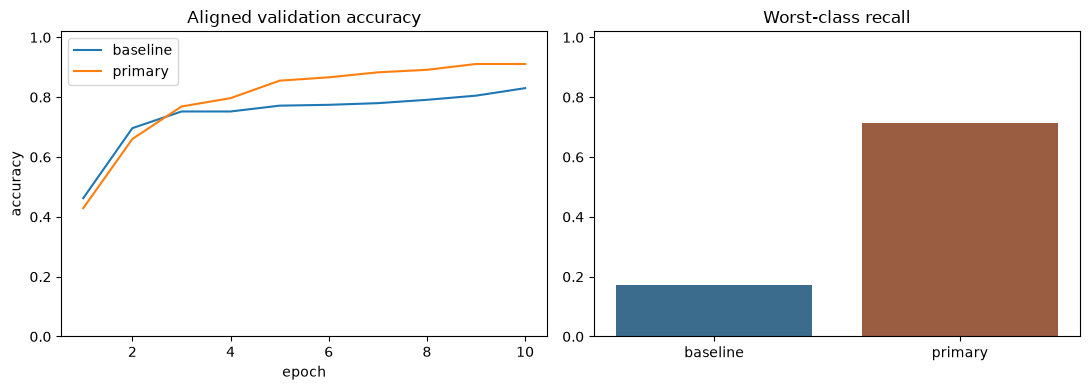

In [ ]:
primary_confusion = confusion_matrix(y_all[val_indices], primary_validation["predictions"], labels=np.arange(10))
primary_recall = np.diag(primary_confusion) / np.maximum(primary_confusion.sum(1), 1)
baseline_val_loss_deltas = np.diff(baseline["val_loss"])
primary_val_loss_deltas = np.diff(primary_history["val_loss"])
baseline_val_loss_variation = float(np.abs(baseline_val_loss_deltas).sum())
primary_val_loss_variation = float(np.abs(primary_val_loss_deltas).sum())
baseline_val_loss_upward_variation = float(np.clip(baseline_val_loss_deltas, 0, None).sum())
primary_val_loss_upward_variation = float(np.clip(primary_val_loss_deltas, 0, None).sum())
comparison = {
    "accuracy_delta": primary_validation["accuracy"] - baseline_summary["validation_accuracy"],
    "macro_f1_delta": primary_validation["macro_f1"] - baseline_summary["validation_macro_f1"],
    "worst_recall_delta": float(primary_recall.min()) - baseline_summary["worst_class_recall"],
    "gap_before": baseline_summary["train_accuracy"] - baseline_summary["validation_accuracy"],
    "gap_after": float(primary_history["train_accuracy"][-1]) - primary_validation["accuracy"],
    "baseline_val_loss_total_variation": baseline_val_loss_variation,
    "primary_val_loss_total_variation": primary_val_loss_variation,
    "baseline_val_loss_upward_variation": baseline_val_loss_upward_variation,
    "primary_val_loss_upward_variation": primary_val_loss_upward_variation,
}
comparison["gap_reduction"] = comparison["gap_before"] - comparison["gap_after"]
comparison["stability_improved"] = primary_val_loss_upward_variation < baseline_val_loss_upward_variation
TARGET_CHECKS = {
    "A": {
        "passed": comparison["worst_recall_delta"] >= 0.05 and comparison["accuracy_delta"] >= -0.02,
        "rule": "worst recall gain >= 0.05 and validation accuracy delta >= -0.02",
    },
    "B": {
        "passed": comparison["gap_reduction"] >= 0.025 or comparison["accuracy_delta"] > 0.0,
        "rule": "gap reduction about 0.03 or a defensible positive validation delta",
    },
    "C": {
        "passed": comparison["accuracy_delta"] >= 0.05 and comparison["stability_improved"],
        "rule": "validation accuracy gain >= 0.05 and lower validation-loss upward variation",
    },
}
target_check = TARGET_CHECKS[PROFILE_ID]
print("Comparison:", comparison)
print("Assigned target check:", target_check)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(baseline["epochs"], baseline["val_accuracy"], label="baseline"); axes[0].plot(range(1, len(primary_history["val_accuracy"]) + 1), primary_history["val_accuracy"], label="primary")
axes[0].set(title="Aligned validation accuracy", xlabel="epoch", ylabel="accuracy", ylim=(0, 1.02)); axes[0].legend()
axes[1].bar(["baseline", "primary"], [baseline_summary["worst_class_recall"], float(primary_recall.min())], color=["#3b6c8e", "#9b5d42"])
axes[1].set(title="Worst-class recall", ylim=(0, 1.02)); plt.tight_layout(); plt.show()

## Serialize the Ledger and Evidence Board

Separate facts, inference, prediction, observed result, and interpretation. No test evidence belongs here yet.

In [ ]:
INTERPRETATIONS = {
    "A": {
        "observed_result": f"Validation accuracy changed {comparison['accuracy_delta']:+.4f}, macro-F1 {comparison['macro_f1_delta']:+.4f}, and worst-class recall {comparison['worst_recall_delta']:+.4f}.",
        "interpretation": "The target passes, so class-sensitive loss contribution is supported and narrowed; representation and label ambiguity remain plausible secondary causes.",
        "next_step": "Audit weak-class labels and collect or rebalance targeted examples under a predeclared slice/aggregate tolerance.",
    },
    "B": {
        "observed_result": f"Validation accuracy changed {comparison['accuracy_delta']:+.4f}; the train/validation gap moved from {comparison['gap_before']:.4f} to {comparison['gap_after']:.4f}, a {comparison['gap_reduction']:+.4f} reduction.",
        "interpretation": "The target passes without collapsing held-out quality, supporting and narrowing the capacity/variance mechanism; one split cannot eliminate distribution shift.",
        "next_step": "Repeat the fixed comparison on a predeclared alternate split or seed before selecting a smaller architecture or data intervention.",
    },
    "C": {
        "observed_result": f"Validation accuracy changed {comparison['accuracy_delta']:+.4f}; validation-loss upward variation moved from {comparison['baseline_val_loss_upward_variation']:.4f} to {comparison['primary_val_loss_upward_variation']:.4f}.",
        "interpretation": "The target passes with a smoother path, supporting and narrowing the aggressive-step-size mechanism; representation limits remain untested.",
        "next_step": "With optimization stabilized, run one width or invariant check under the same split and learning rate to test residual capacity limits.",
    },
}
profile_interpretation = INTERPRETATIONS[PROFILE_ID]
experiment_ledger = {
    "schema": 1,
    "profile": PROFILE_ID,
    "case_target": case_target,
    "split_hash": split_hash,
    "data_source": "sklearn.datasets.load_digits",
    "selected_baseline_artifact": {"path": selected_baseline_record["path"], "sha256": selected_baseline_record["sha256"]},
    "device": str(DEVICE),
    "versions": {"torch": torch.__version__, "numpy": np.__version__, "sklearn": sklearn.__version__},
    "evidence_request": evidence_request,
    "requested_evidence": requested_evidence,
    "diagnosis_gate": diagnosis_gate,
    "baseline_config": BASELINE_CONFIG,
    "primary_config": PRIMARY_CONFIG,
    "changed_field": changed_fields[0],
    "intervention_prediction": intervention_prediction,
    "baseline_metrics": baseline_summary,
    "primary_metrics": {
        "accuracy": primary_validation["accuracy"],
        "macro_f1": primary_validation["macro_f1"],
        "worst_class_recall": float(primary_recall.min()),
    },
    "comparison": comparison,
    "target_check": target_check,
    "resources": {**primary_resources, "method": "CPU; model.eval; torch.inference_mode; batch 1; warmup and repeats recorded"},
    "recovery_used": recovery_used,
    "recovery_provenance": recovery_provenance,
}
evidence_board = {
    "baseline_facts": f"Train/validation accuracy {baseline_summary['train_accuracy']:.4f}/{baseline_summary['validation_accuracy']:.4f}; macro-F1 {baseline_summary['validation_macro_f1']:.4f}; worst recall {baseline_summary['worst_class_recall']:.4f}; selected artifact hash verified.",
    "diagnosis": diagnosis_gate["primary_limitation"],
    "threatening_evidence": diagnosis_gate["competing_explanation"] + " " + diagnosis_gate["disconfirming_evidence"],
    "prediction": intervention_prediction["predicted_metric"] + " " + intervention_prediction["predicted_curve_or_slice"],
    "observed_result": profile_interpretation["observed_result"],
    "interpretation": profile_interpretation["interpretation"],
    "cost_or_constraint": f"Primary bytes {primary_resources['parameter_bytes']}; training {primary_resources['training_seconds']:.4f}s; batch-1 median/p90 {primary_resources['median_ms']:.4f}/{primary_resources['p90_ms']:.4f} ms on this host.",
    "next_step": profile_interpretation["next_step"],
}
assert all(value.strip() for value in evidence_board.values())
serialized_ledger = json.dumps(experiment_ledger, sort_keys=True, indent=2)
serialized_board = json.dumps(evidence_board, sort_keys=True, indent=2)
json.loads(serialized_ledger); json.loads(serialized_board)
print("Ledger and evidence board serialized.")

## Decision Gate Before Test

Accept, reject, or revise the diagnosis. State whether the case target was met, what regression is unacceptable, and what choice is now frozen. This decision consumes validation evidence; test remains untouched until the gate passes.

In [14]:
EXPECTED_TEST_RANGES = {
    "A": "accuracy and macro-F1 about 0.90-0.94",
    "B": "accuracy and macro-F1 about 0.87-0.92",
    "C": "accuracy and macro-F1 about 0.87-0.92",
}
decision_record = {
    "diagnosis_status": profile_interpretation["interpretation"],
    "target_met_or_not": f"{'Met' if target_check['passed'] else 'Not met'}: {target_check['rule']}.",
    "supporting_delta": profile_interpretation["observed_result"] + f" Expected locked test range: {EXPECTED_TEST_RANGES[PROFILE_ID]}.",
    "unacceptable_regression_check": intervention_prediction["rejection_rule"],
    "frozen_model_choice": "Primary live model" if primary_run is not None and target_check["passed"] else ("Baseline live model" if primary_run is not None else "Cached validation record for defense only; no test/deployment claim"),
    "why_no_more_validation_tuning": "The predeclared one-change result resolved the primary question; further selection would spend the optional budget without a higher-information unresolved question.",
}
assert all(value.strip() for value in decision_record.values())
if primary_run is not None:
    TEST_AUTHORIZED = True
    X_test, y_test = access_test_split()
    print("Test authorized after the live decision; count:", len(y_test))
else:
    X_test = y_test = None
    assert not TEST_AUTHORIZED and TEST_ACCESS_COUNT == 0
    print("Recovery remains validation-only; test was not authorized or bound.")

Test authorized after the live decision; count: 360


In [15]:
if primary_run is not None:
    assert TEST_AUTHORIZED and TEST_ACCESS_COUNT == 1
    test_metrics = evaluate_model(primary_run["model"], X_test, y_test)
    authorized_test_record = {
        "accuracy": test_metrics["accuracy"],
        "macro_f1": test_metrics["macro_f1"],
        "expected_range_before_access": EXPECTED_TEST_RANGES[PROFILE_ID],
        "claim_update": "The held-out result is consistent with the locked validation claim; no further tuning is authorized.",
        "used_for_further_tuning": False,
    }
else:
    assert not TEST_AUTHORIZED and TEST_ACCESS_COUNT == 0 and X_test is None and y_test is None
    authorized_test_record = {
        "status": "not authorized or available from validation-only recovery artifact",
        "expected_range_before_access": EXPECTED_TEST_RANGES[PROFILE_ID],
        "claim_update": "No test claim; continue the validation defense with cached provenance visible.",
        "used_for_further_tuning": False,
    }
print("Authorized test record:", authorized_test_record)

Authorized test record: {'accuracy': 0.9222222222222223, 'macro_f1': 0.922301548820419, 'expected_range_before_access': 'accuracy and macro-F1 about 0.90-0.94', 'claim_update': 'The held-out result is consistent with the locked validation claim; no further tuning is authorized.', 'used_for_further_tuning': False}


## Optional Bounded Follow-Up

Only after the primary decision and test record, name a second intervention. The optional branch may run once for learning, but it must not replace the frozen test claim or trigger another test evaluation.

In [16]:
OPTIONAL_PLANS = {
    "A": {
        "single_change": "weight_decay: 0.0 -> 0.001 relative to the accepted weighted-loss primary config",
        "reason": "Test whether mild parameter shrinkage changes the remaining representation/generalization uncertainty after the class-aware target passed.",
        "predicted_validation_evidence": "Worst-class recall should remain improved and aggregate validation should stay within 0.02; otherwise the extra regularizer is not useful.",
        "why_test_stays_closed": "This is validation-only sensitivity evidence after the frozen test claim and cannot trigger another test access.",
        "field": "weight_decay", "value": 0.001,
    },
    "B": {
        "single_change": "hidden: [256, 128] -> [128] relative to the accepted dropout primary config",
        "reason": "Test whether lower capacity preserves validation quality while reducing bytes, separating a resource/capacity question from split shift.",
        "predicted_validation_evidence": "Validation should stay within about 0.02 while parameter bytes fall; a larger regression rejects this smaller model for the current evidence.",
        "why_test_stays_closed": "The original test claim is frozen; optional model selection against test would invalidate generalization evidence.",
        "field": "hidden", "value": [128],
    },
    "C": {
        "single_change": "optimizer_name: adam -> adamw relative to the accepted 0.003-learning-rate primary config",
        "reason": "Check whether optimizer formulation matters after step-size stability is restored without changing architecture or test evidence.",
        "predicted_validation_evidence": "The path should remain stable and validation should stay near the primary result; a material regression rejects the optional optimizer.",
        "why_test_stays_closed": "This follow-up is learning-only validation evidence and cannot replace or recompute the frozen test claim.",
        "field": "optimizer_name", "value": "adamw",
    },
}
optional_plan = dict(OPTIONAL_PLANS[PROFILE_ID])
optional_follow_up = {key: optional_plan[key] for key in ["single_change", "reason", "predicted_validation_evidence", "why_test_stays_closed"]}
assert all(value.strip() for value in optional_follow_up.values())
RUN_OPTIONAL_FOLLOW_UP = os.environ.get("DAY4_RUN_OPTIONAL", "1") == "1" and not recovery_used
optional_run = None
if RUN_OPTIONAL_FOLLOW_UP:
    OPTIONAL_CONFIG = dict(PRIMARY_CONFIG)
    OPTIONAL_CONFIG[optional_plan["field"]] = optional_plan["value"]
    optional_changed = [field for field in MAJOR_FIELDS if OPTIONAL_CONFIG[field] != PRIMARY_CONFIG[field]]
    assert optional_changed == [optional_plan["field"]]
    test_accesses_before_optional = TEST_ACCESS_COUNT
    optional_run = run_experiment(OPTIONAL_CONFIG, case_train_indices, val_indices)
    assert TEST_ACCESS_COUNT == test_accesses_before_optional
    optional_result = {
        "status": "executed validation-only",
        "changed_field": optional_changed[0],
        "validation_accuracy": optional_run["validation"]["accuracy"],
        "validation_macro_f1": optional_run["validation"]["macro_f1"],
        "parameter_bytes": optional_run["parameter_bytes"],
        "test_reused": False,
    }
else:
    optional_result = {
        "status": "not spent because recovery mode preserves validation-only evidence" if recovery_used else "not spent by instructor selector",
        "planned_change": optional_follow_up["single_change"],
        "test_reused": False,
    }
print("Optional decision:", optional_result)

Optional decision: {'status': 'executed validation-only', 'changed_field': 'weight_decay', 'validation_accuracy': 0.9108635097493036, 'validation_macro_f1': 0.9092309633189057, 'parameter_bytes': 9640, 'test_reused': False}


## Defense Fields

Prepare a five-minute team defense: what was wrong, what evidence supports and threatens that view, what changed, what happened, why, what it cost, and what should happen next. Do not add an individual transfer response to the team artifact. After the team defense, each participant completes [CHECK-D4-04](../day-4/assessments/day-4-checks.md#check-d4-04---individual-frontier-transfer) separately.

In [17]:
defense = {
    "problem_and_consequence": f"Profile {PROFILE_ID}: {case_target} Aggregate accuracy alone can hide class harm, unstable fitting, or a large train/validation gap.",
    "primary_diagnosis": diagnosis_gate["primary_limitation"],
    "supporting_evidence": diagnosis_gate["supporting_metric"] + " " + diagnosis_gate["supporting_curve_or_slice"],
    "disconfirming_or_threatening_evidence": diagnosis_gate["competing_explanation"] + " Rejection rule: " + intervention_prediction["rejection_rule"],
    "single_intervention": f"Changed only {changed_fields[0]} from {BASELINE_CONFIG[changed_fields[0]]!r} to {PRIMARY_CONFIG[changed_fields[0]]!r}; all other major fields, split, seed, metrics, and budget stayed fixed.",
    "observed_result": profile_interpretation["observed_result"] + f" Target pass={target_check['passed']}.",
    "mechanism_explanation": profile_interpretation["interpretation"] + " The result updates a causal hypothesis but does not uniquely prove it.",
    "efficiency_and_reproducibility": f"CPU, one PyTorch thread; split {split_hash}; source SHA-256 {selected_baseline_record['sha256']}; {primary_resources['parameter_bytes']} bytes; batch-1 median/p90 {primary_resources['median_ms']:.4f}/{primary_resources['p90_ms']:.4f} ms after {primary_resources['warmup']} warmups over {primary_resources['repeats']} repeats. Latency is host-specific.",
    "test_statement": (f"One live test access occurred after the frozen decision; accuracy/macro-F1 {authorized_test_record['accuracy']:.4f}/{authorized_test_record['macro_f1']:.4f}; it was not used for tuning." if primary_run is not None else "Cached recovery remained validation-only: no test authorization, arrays, metric, checkpoint, or deployment claim."),
    "next_experiment": profile_interpretation["next_step"],
}
assert set(defense) == {
    "problem_and_consequence", "primary_diagnosis", "supporting_evidence",
    "disconfirming_or_threatening_evidence", "single_intervention", "observed_result",
    "mechanism_explanation", "efficiency_and_reproducibility", "test_statement", "next_experiment",
}
assert "individual_transfer" not in defense
assert all(value.strip() for value in defense.values())

## Challenge and Reflection

Challenge your own case: write the strongest alternative explanation that remains consistent with the evidence and the cheapest new observation that would separate it from your current view. Then identify one way the small digits framing fails to represent a production routing system.

In [18]:
REFLECTIONS = {
    "A": {
        "strongest_alternative": "Representation overlap or label ambiguity could create weak recall even when support is corrected; weighting may only change the error trade-off.",
        "cheapest_discriminating_observation": "Review a predeclared sample of weak-class errors and compare per-class support/recall under one balanced-sampling or targeted-data run without changing architecture.",
        "simulation_limit": "Small clean 8x8 digits omit routing handwriting diversity, acquisition shift, abstention, human review cost, and operational failure modes.",
        "what_you_would_monitor": "Per-class recall/support, macro-F1, aggregate accuracy, confidence calibration, drift, review load, latency tails, and label quality.",
    },
    "B": {
        "strongest_alternative": "The fixed case subset and validation split may differ, so split shift rather than model capacity could explain the gap and dropout response.",
        "cheapest_discriminating_observation": "Repeat the locked baseline/dropout comparison on one predeclared alternate stratified split or seed and inspect whether the gap and validation direction persist.",
        "simulation_limit": "The tiny static dataset and in-memory CPU timing do not represent production routing volume, drift, service latency, or retraining constraints.",
        "what_you_would_monitor": "Train/validation gap, slice quality, calibration, drift, duplicate/label audits, model bytes, throughput, and p90/p99 service latency.",
    },
    "C": {
        "strongest_alternative": "A compact representation or preprocessing invariant may still limit quality; the lower learning rate can stabilize training without resolving that ceiling.",
        "cheapest_discriminating_observation": "After confirming normalization/loss invariants, run one predeclared width-only comparison at learning rate 0.003 and reject capacity if held-out quality does not move.",
        "simulation_limit": "A deterministic digits classroom run does not establish robustness to handwriting shift, corrupted inputs, latency load, or production-scale optimization.",
        "what_you_would_monitor": "Loss spikes, gradient/update norms, train/validation quality, class recall, drift, numerical failures, latency tails, and rollback triggers.",
    },
}
reflection = dict(REFLECTIONS[PROFILE_ID])
assert all(value.strip() for value in reflection.values())

## Takeaways and Troubleshooting

- The deliverable is a defensible decision trail, not only a score delta.
- Test is a limited final estimate, not an iterative diagnosis surface.
- One requested evidence card and one primary intervention enforce information discipline.
- Recovery artifacts preserve validation defense after technical failure but deliberately contain no cause, intervention, checkpoint, or test result.
- The team artifact ends with the defense. `CHECK-D4-04` is a separate individual submission and is never added to the 100-point team score.

| Symptom | Likely cause | Instructor recovery |
|---|---|---|
| Test access raises `PermissionError` | Decision gate incomplete or recovery mode active | Finish and freeze the live decision; never authorize test for cached recovery |
| Second test access raises `RuntimeError` | The one-access budget was already consumed | Preserve the first record and stop; do not reset the counter |
| Recovery fingerprint mismatch | Cached run does not match the committed config | Use the live run or defend baseline evidence; never bypass/relabel recovery |
| Recovery safety assertion fails | Artifact schema/string contract changed | Stop delivery and revalidate support generation; do not expose the artifact |
| More than one changed field | Confounded intervention | Reset from the assigned artifact-loaded baseline config |
| Profile metrics differ | Split, seed, package, or config changed | Restore the manifest split/hash and compare within calibrated ranges |
| Plot is blank | Backend/render failure | Preserve numeric arrays and rerun plotting after the evidence decision |
| Runtime approaches 12 minutes | Optional/epoch budget expanded or thread/device changed | Stop after the bounded primary run and use exact recovery if a technical failure persists |
| Hosted path cannot find data | Shared Day 4 directory was not uploaded at repository-relative path | Restore the full `courseware/shared/data/day-4/` tree; hosted Colab remains unvalidated |

**Fast live recovery:** preserve the pre-run prediction, record the first failing invariant, attempt one bounded repair, then set `DAY4_USE_RECOVERY=1` and restart/run all. The result must display cached provenance and no test claim.

In [19]:
RUBRIC_SCORES = {
    "model_performance": 25,
    "generalization": 20,
    "experimental_design": 20,
    "diagnosis": 15,
    "efficiency": 10,
    "explanation": 10,
}
assert sum(RUBRIC_SCORES.values()) == 100
assert split_hash == manifest["fixed_split"]["hash"]
assert len(changed_fields) == 1 and target_check["passed"]
assert recovery_used == (primary_run is None)
assert TEST_AUTHORIZED == (primary_run is not None)
assert TEST_ACCESS_COUNT == (1 if primary_run is not None else 0)
assert not authorized_test_record["used_for_further_tuning"] and not optional_result["test_reused"]
assert "individual_transfer" not in defense and len(defense) == 10
json.loads(serialized_ledger); json.loads(serialized_board)
assert all(value.strip() for value in defense.values())
assert all(value.strip() for value in reflection.values())
completed_seconds = time.perf_counter() - started_capstone
assert completed_seconds < 12 * 60
execution_mode = "cached validation-only recovery" if recovery_used else "live training with one authorized test"
print(f"LAB-D4-04 checkpoint passed for profile {PROFILE_ID} in {completed_seconds:.2f}s ({execution_mode}): target passed, ledger/board serialized, test policy honored, team rubric 100, and defense complete.")

LAB-D4-04 checkpoint passed for profile A in 1.28s (live training with one authorized test): target passed, ledger/board serialized, test policy honored, team rubric 100, and defense complete.


## Submit

Return to the [Day 4 capstone debrief](../day-4/student-guide/day-4-student-guide.md#capstone-debrief) and check every field against the [Capstone Rubric](capstone-rubric.md). Keep the serialized ledger and evidence board with your participant submission.

---

## Instructor-Only Debrief: Opaque Selector and Case Dispositions

Set `DAY4_PROFILE=A|B|C` before **Restart Kernel -> Run All**; default is `A`. The learner-sequence cells load only `profile_<letter>_baseline` from the manifest, verify its SHA-256, and derive `case_target`, `case_train_indices`, and `BASELINE_CONFIG` from that selected artifact. There is no cross-profile configuration map or train-index construction helper in the mirrored path.

| Profile | What the evidence supports | Why the primary run is informative | Concept exposed | Strongest remaining alternative |
|---|---|---|---|---|
| A | limited class support/loss contribution harms worst recall | class weighting changes one loss factor while data and capacity stay fixed | aggregate metrics can hide consequential slice harm | representation overlap or label ambiguity |
| B | capacity on constrained data contributes to variance | dropout changes one regularizer while width/data/optimizer stay fixed | a gap needs absolute levels, path, and held-out quality | split shift or unrepresentative data |
| C | an aggressive learning rate destabilizes fit | one step-size correction holds architecture and optimizer family fixed | stabilize optimization before diagnosing capacity | representation or preprocessing invariant |

These are calibration dispositions, not labels participants must guess. A coherent off-key intervention can score strongly when evidence, controls, rejection criteria, and claim boundaries are sound.

## Expected Evidence and Acceptable Ranges

| Profile | Baseline validation / macro-F1 / worst recall | Primary validation / macro-F1 | Required target evidence | Locked live test band |
|---|---|---|---|---|
| A | about `0.830 / 0.801 / 0.171` | about `0.911 / 0.910` | worst recall gain at least `+0.05`; validation delta no worse than `-0.02` (recorded `+0.543 / +0.081`) | accuracy and macro-F1 about `0.90-0.94` |
| B | about `0.880 / 0.881 / 0.714`, train `1.000` | about `0.911 / 0.910` | gap reduction about `0.03` or defensible positive validation delta (recorded `0.0306 / +0.0306`) | accuracy and macro-F1 about `0.87-0.92` |
| C | about `0.783 / 0.768 / 0.229` | about `0.897 / 0.896` | validation gain at least `+0.05` and lower validation-loss upward variation (recorded `+0.114`; `0.2738 -> 0.0000`) | accuracy and macro-F1 about `0.87-0.92` |

Grade calibrated direction and internally consistent arithmetic, not exact floating-point identity across supported environments. Split hash, selected artifact SHA-256, config fingerprint, changed-field count, and parameter bytes should be exact for the same contract. Training time and warmed batch-1 latency are host-specific; require method and environment rather than a universal threshold.

## Test Lock, Recovery, and Optional Path

**Live path:** the early lock call must raise `PermissionError` with access count zero. Only after diagnosis, one-change run, comparison, serialized ledger/board, target decision, frozen model choice, and expected test range does the solution authorize exactly one access. A second call raises `RuntimeError`; the test record states `used_for_further_tuning=False`.

**Recovery path:** set `DAY4_USE_RECOVERY=1` before a fresh run. Recovery is selected by the committed-config fingerprint and manifest SHA-256, then scanned for cause, diagnosis, intervention, checkpoint, and test terms. It provides validation curves/predictions/resources only. `TEST_AUTHORIZED` remains false, access count remains zero, test arrays are not bound, and the defense states that no test/deployment claim is available.

**Optional path:** live runs default to one validation-only instructor demonstration (`DAY4_RUN_OPTIONAL=1`): A adds mild weight decay, B reduces width, and C switches to AdamW. The code proves the test counter does not change. Recovery skips optional training because a technical-failure path should preserve the exact cached defense rather than start a new experiment. In class, not spending the optional run is often the stronger decision unless it separates a named residual uncertainty.

## Alternatives, Hint Ladders, and Common Wrong Diagnoses

| Profile | Acceptable one-factor alternatives | Hint ladder | Common wrong diagnosis and correction |
|---|---|---|---|
| A | balanced sampler, one targeted training-composition change, or a bounded collection plan | (1) compare accuracy and macro-F1; (2) locate worst recall; (3) request class counts; (4) ask which loss/data change tests support without changing capacity | "Low accuracy proves underfitting." Weak class support is a different mechanism; weighting sensitivity does not prove it is the sole cause. |
| B | smaller width, one weight-decay/dropout value, predeclared early stopping, or more representative training data | (1) compare absolute train/validation levels; (2) inspect the late path; (3) request curve dynamics; (4) hold data and optimizer fixed while changing one regularizer | "Any smaller gap is improvement." A gap can shrink because training collapses; held-out quality and slices must remain useful. |
| C | one optimizer change under fixed settings or an invariant/normalization repair when evidence supports it | (1) compare weak train and validation levels; (2) inspect oscillation; (3) request curve dynamics; (4) stabilize one optimization factor before testing capacity | "Weak validation proves overfitting." Weak training plus instability points elsewhere; a corrected learning rate still does not prove architecture is irrelevant. |

For any profile, reject random sweeps, simultaneous major changes, test-driven checkpoint selection, and unsupported production claims. Ask, in order: **What did you observe? What alternatives predict it? Why does this one change discriminate? What result would make you wrong?**

## Scoring Anchors and Instructor Operations

The team rubric is exactly **25 model performance + 20 generalization + 20 experimental design + 15 diagnosis + 10 efficiency + 10 explanation = 100**. Each learner submits the separate five-line `CHECK-D4-04` after the defense; it is recorded independently and never added to team arithmetic.

| Dimension | Strong anchor |
|---|---|
| Model performance `25` | aligned baseline/primary metric, relevant class evidence, tolerance, and honest null/negative handling |
| Generalization `20` | distinct train/validation/test roles, validation-selected checkpoint, one locked test look, calibrated claim |
| Experimental design `20` | falsifiable hypothesis, one major change, kept-fixed contract, pre-run predictions/rejection rule, complete ledger |
| Diagnosis `15` | ranked hypotheses, two independent observations, genuine competitor, disconfirming evidence, updated status |
| Efficiency `10` | bounded run budget, bytes plus warmed repeated timing/method/environment, no low-information test or optional reuse |
| Explanation `10` | facts -> hypothesis -> prediction -> result -> interpretation -> next step, plus digits-to-production limitation |

**Demo notes:** pause before the evidence reveal and ask which alternatives the card separates; before compute, circle the one changed field and rejection rule; before test, have the instructor read the frozen choice and expected range aloud. During defense, ask which observation most threatened the diagnosis and which resource number is least portable.

**Fast recovery:** preserve the prediction and first failed invariant, attempt one bounded repair, restart with the exact profile and `DAY4_USE_RECOVERY=1`, verify the fingerprint/SHA-256 and visible cached provenance, then continue the validation defense with no test claim. Never distribute this solution notebook or the case key as recovery material.

Run on one local CPU thread with the complete repository-relative Day 4 data directory. The validated local path should produce three nonblank plots far below 12 minutes. Hosted Google Colab was not executed; upload/path practicality is plausible but **hosted readiness remains unvalidated**. Cross-device identity and production latency are also unvalidated.